In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/DatasetforDataAnalytics.xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [3]:
import pandas as pd

# Assuming your dataset is already loaded:
# df = pd.read_csv('cleaned_project1_data.csv')

# 1. Isolate the numerical variables for univariate analysis
numerical_metrics = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# 2. Generate the Five-Number Summary, Mean, and Count
# The .describe() method efficiently provides the Count, Mean, Min, 25% (Q1), 50% (Median), 75% (Q3), and Max.
summary_stats = df[numerical_metrics].describe()

print("### Five-Number Summary & Basic Statistics ###")
print(summary_stats)
print("-" * 50)

# 3. Compare Mean vs. Median to determine the shape of the evidence
# We will create a focused DataFrame to put the Mean and Median side-by-side
shape_diagnostics = pd.DataFrame({
    'Mean': df[numerical_metrics].mean(),
    'Median': df[numerical_metrics].median()
})

# 4. Apply analytical logic to classify the distribution
def diagnose_shape(row):
    # Using a 1% threshold to account for minor floating-point variances
    threshold = row['Median'] * 0.01

    if row['Mean'] > (row['Median'] + threshold):
        return "Skewed Right (Mean > Median)"
    elif row['Mean'] < (row['Median'] - threshold):
        return "Skewed Left (Mean < Median)"
    else:
        return "Symmetrical (Mean ≈ Median)"

shape_diagnostics['Shape Verdict'] = shape_diagnostics.apply(diagnose_shape, axis=1)

print("\n### Distribution Shape Analysis ###")
print(shape_diagnostics)

### Five-Number Summary & Basic Statistics ###
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000
--------------------------------------------------

### Distribution Shape Analysis ###
                    Mean   Median                 Shape Verdict
Quantity        2.945833    3.000   Skewed Left (Mean < Median)
UnitPrice     356.412750  364.210   Skewed Left (Mean < Median)
ItemsInCart     5.485000    5.000  Skewed Right (Mean > Median)
TotalPrice   1053.968300  823.615  Skewed Right (Mean > Median)


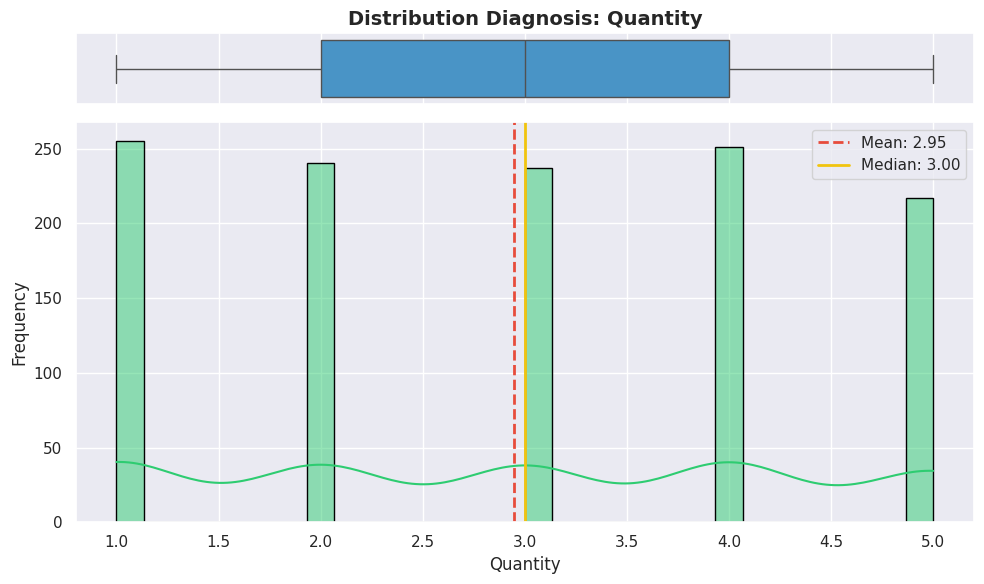

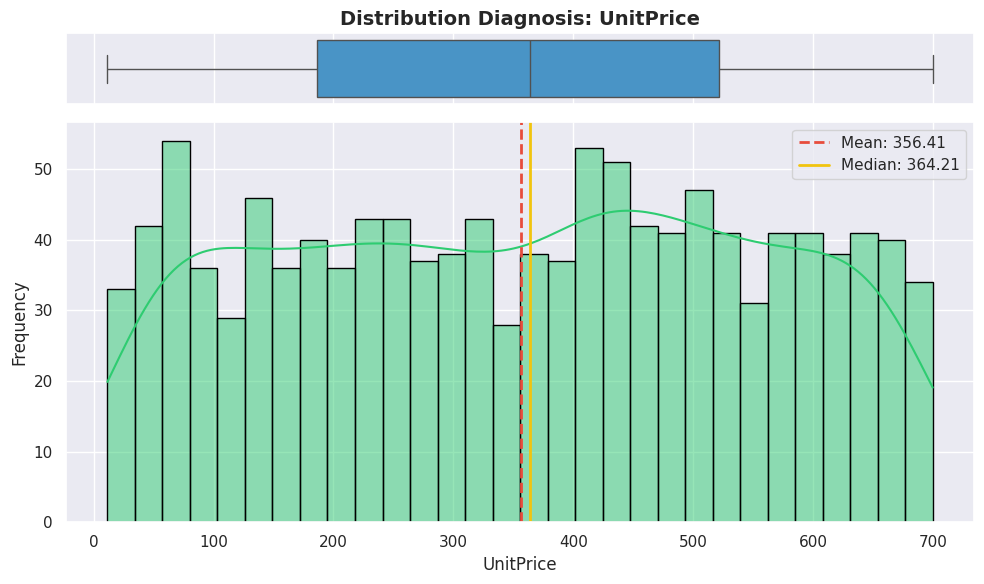

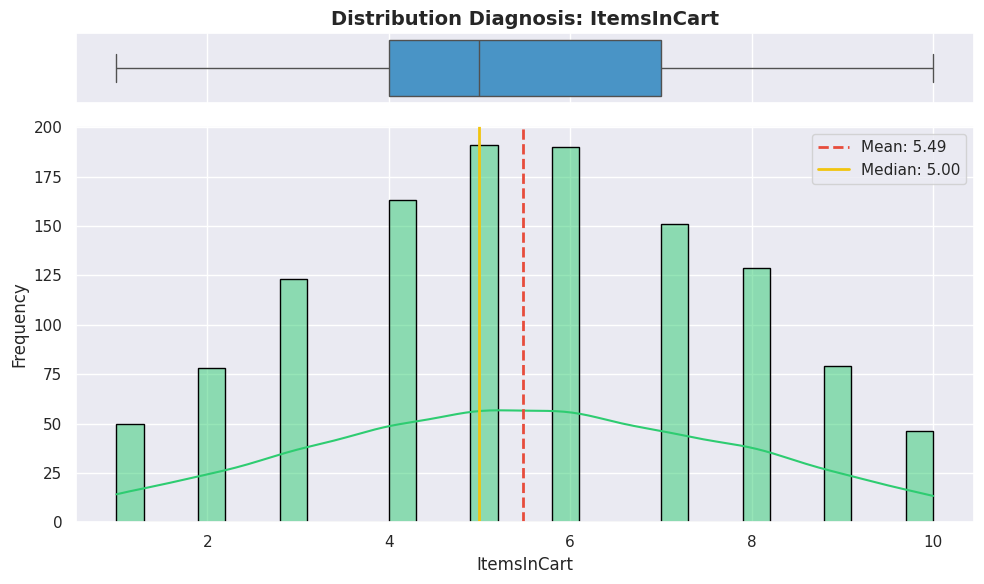

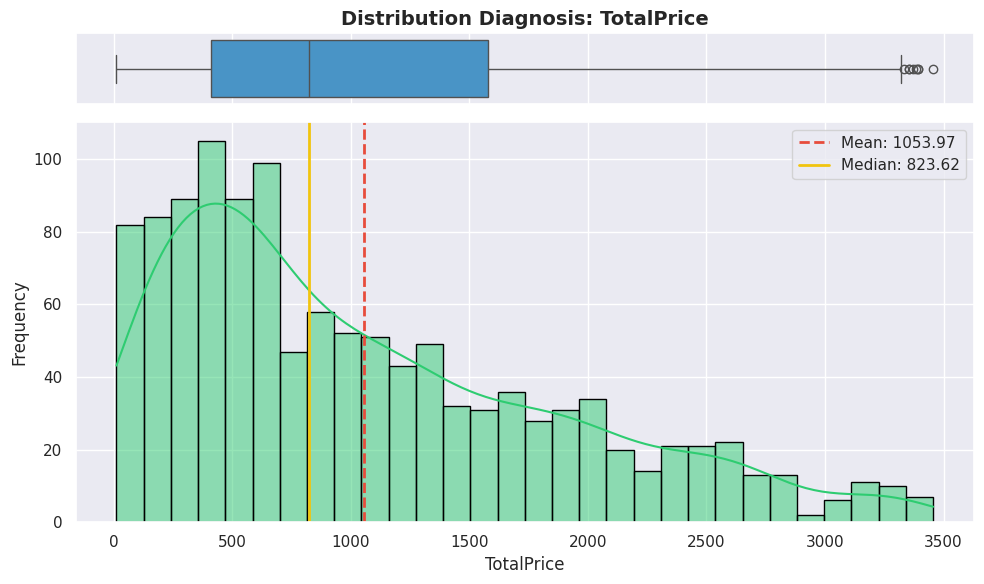

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataset is already loaded:
# df = pd.read_csv('cleaned_project1_data.csv')

# The numerical evidence we are investigating
numerical_metrics = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# Set the visual style for our forensic dashboard
sns.set_theme(style="darkgrid", palette="mako")

# Loop through each metric to draw its shape and fingerprint
for col in numerical_metrics:
    # Create a figure with two subplots: Boxplot on top, Histogram below
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.15, .85)},
        figsize=(10, 6)
    )

    # 1. The Fingerprint of Variability (Boxplot)
    # This highlights the Median (The Truth) and Whiskers (Expected Range)
    sns.boxplot(x=df[col], ax=ax_box, color="#3498db")
    ax_box.set(xlabel='') # Hide the x-label for the boxplot to keep it clean
    ax_box.set_title(f"Distribution Diagnosis: {col}", fontsize=14, fontweight='bold')

    # 2. The Geometry of Distribution (Histogram with KDE)
    # The KDE (Kernel Density Estimate) draws the smooth curve over the bars
    sns.histplot(data=df, x=col, ax=ax_hist, kde=True, bins=30, color="#2ecc71", edgecolor="black")

    # Plot the Mean and Median lines to visually verify our center of gravity
    mean_val = df[col].mean()
    median_val = df[col].median()

    ax_hist.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='#f1c40f', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    ax_hist.set_xlabel(col, fontsize=12)
    ax_hist.set_ylabel('Frequency', fontsize=12)
    ax_hist.legend()

    # Render the evidence
    plt.tight_layout()
    plt.show()

In [5]:
import pandas as pd
import numpy as np

# Assuming 'df' is loaded from your Phase 1 output
numerical_metrics = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

def apply_iqr_method(data, col):
    """
    Applies the IQR method. Best for skewed data (like TotalPrice).
    """
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter for the outliers
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

def apply_zscore_method(data, col):
    """
    Applies the Z-Score method. Best for normally distributed data.
    """
    mean = data[col].mean()
    std_dev = data[col].std()

    # Calculate Z-scores
    z_scores = (data[col] - mean) / std_dev

    # Filter for outliers (Z-score > 3 or < -3)
    outliers = data[(z_scores > 3) | (z_scores < -3)]
    return outliers

print("### OUTLIER DIAGNOSTICS REPORT ###\n")

for col in numerical_metrics:
    print(f"--- Investigating: {col} ---")

    # 1. IQR Method
    iqr_outliers, low, high = apply_iqr_method(df, col)
    print(f"IQR Method: Found {len(iqr_outliers)} potential outliers.")
    print(f"    Expected bounds: {low:.2f} to {high:.2f}")

    # 2. Z-Score Method
    z_outliers = apply_zscore_method(df, col)
    print(f"Z-Score Method: Found {len(z_outliers)} potential outliers.")
    print("-" * 40)

### OUTLIER DIAGNOSTICS REPORT ###

--- Investigating: Quantity ---
IQR Method: Found 0 potential outliers.
    Expected bounds: -1.00 to 7.00
Z-Score Method: Found 0 potential outliers.
----------------------------------------
--- Investigating: UnitPrice ---
IQR Method: Found 0 potential outliers.
    Expected bounds: -317.20 to 1024.83
Z-Score Method: Found 0 potential outliers.
----------------------------------------
--- Investigating: ItemsInCart ---
IQR Method: Found 0 potential outliers.
    Expected bounds: -0.50 to 11.50
Z-Score Method: Found 0 potential outliers.
----------------------------------------
--- Investigating: TotalPrice ---
IQR Method: Found 8 potential outliers.
    Expected bounds: -1341.41 to 3330.41
Z-Score Method: Found 0 potential outliers.
----------------------------------------


### Pearson Correlation Matrix ###
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity         1.00       0.01         0.65        0.62
UnitPrice        0.01       1.00         0.00        0.72
ItemsInCart      0.65       0.00         1.00        0.39
TotalPrice       0.62       0.72         0.39        1.00
--------------------------------------------------


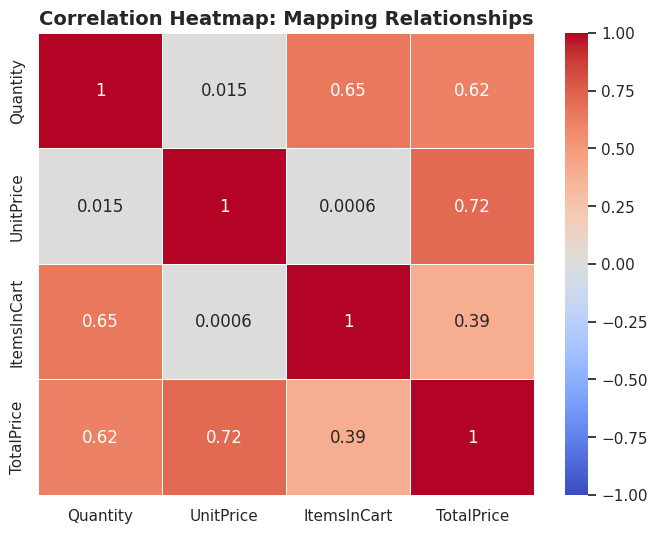

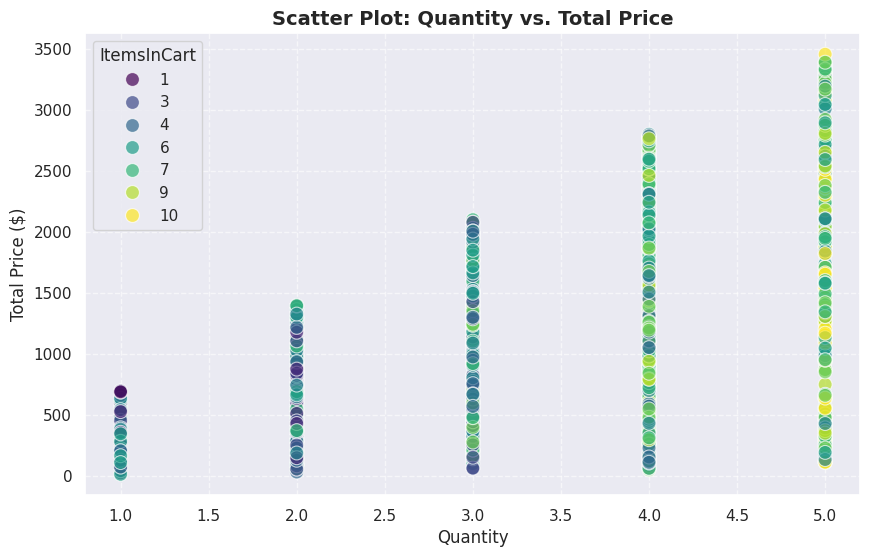

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your loaded DataFrame
numerical_metrics = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# 1. Calculate the Pearson Correlation Coefficient (r)
correlation_matrix = df[numerical_metrics].corr(method='pearson')

print("### Pearson Correlation Matrix ###")
print(correlation_matrix.round(2))
print("-" * 50)

# 2. Visual Evidence: The Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the correlation numbers
    cmap='coolwarm',     # Dark Red = +1.0, Dark Blue = -1.0, White = 0.0
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlation Heatmap: Mapping Relationships", fontsize=14, fontweight='bold')
plt.show()

# 3. Visual Evidence: Scatter Plot (The Confounder Check)
# Let's map Quantity vs TotalPrice, coloring the points by whether they are in the Cart
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice',
    hue='ItemsInCart', # Adds an extra layer of context
    palette='viridis',
    s=100,             # Size of the dots
    alpha=0.7          # Slight transparency to see overlapping data
)
plt.title("Scatter Plot: Quantity vs. Total Price", fontsize=14, fontweight='bold')
plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Total Price ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()